In [1]:
import pandas as pd
from itertools import combinations
import numpy as np

In [2]:
#Loading in the roads data file
df1 = pd.read_csv('./data/_roads3.csv')

# print(df1.head())

#Filtering on only the N1 road
roads = ['N1', 'N2'] + [f'N{i}' for i in range(100, 300)]

dfN = df1[df1['road'].isin(roads)]
# dfN['road'].value_counts()


In [3]:
#Creating the sourcesinks for the new data frame, based on the minimal and maximal chainage


source_rows = dfN.loc[dfN.groupby('road')['chainage'].idxmin()]
sink_rows = dfN.loc[dfN.groupby('road')['chainage'].idxmax()]

df_proc = (
    pd.concat([source_rows, sink_rows])
    .drop_duplicates(subset=['road', 'chainage', 'lrp'])
    .sort_values(['road', 'chainage'])
    .reset_index(drop=True)
)

df_proc


,road,chainage,lrp,lat,lon,gap,type,name
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...
1,N1,462.254,LRPE,20.862917,92.298083,NaN,Others,"End of Road at Shapla Chattar ,Teknaf Meet wit..."
2,N101,0.000,LRPS,23.454139,91.212861,NaN,Others,Start of Road from N120 at Balutopa
3,N101,6.021,LRPE,23.459306,91.253389,NaN,Others,End of road Bibir bazar Bridge
4,N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati
5,N102,82.682,LRPE,24.050611,91.114667,NaN,Others,Meet with N 2 at Sanail
6,N103,0.000,LRPS,23.957028,91.115528,NaN,Others,Road start from N102 at Kuatali.
7,N103,4.779,LRPE,23.996889,91.109278,NaN,Others,Intersection with N102 at Ghaturia.
8,N104,0.000,LRPS,23.009667,91.399416,NaN,Others,Intersection with Z1031
9,N104,49.630,LRPE,22.825749,91.101444,NaN,Others,Meet with Z1441& Z1405 at Sonapur.


In [4]:
df_proc['total_length'] = df_proc.groupby('road')['chainage'].transform('max')

df_filtered = (df_proc[df_proc['total_length'] > 25]).copy()
# df_filtered.drop('total_length', axis=1, inplace=True))
display(df_filtered.head())
df_filtered.road.value_counts()

,road,chainage,lrp,lat,lon,gap,type,name,total_length
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...,462.254
1,N1,462.254,LRPE,20.862917,92.298083,NaN,Others,"End of Road at Shapla Chattar ,Teknaf Meet wit...",462.254
4,N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati,82.682
5,N102,82.682,LRPE,24.050611,91.114667,NaN,Others,Meet with N 2 at Sanail,82.682
8,N104,0.000,LRPS,23.009667,91.399416,NaN,Others,Intersection with Z1031,49.630


road
N1      2
N102    2
N104    2
N105    2
N106    2
N2      2
N204    2
N207    2
N208    2
Name: count, dtype: int64

In [5]:
df_filtered['model_type'] = 'sourcesink'
df_filtered['length'] = 0
df_filtered['condition'] = None

df_filtered = df_filtered[['road', 'lrp', 'model_type', 'name', 'lat', 'lon', 'length', 'condition', 'chainage']]
df_filtered.rename(columns={'lrp': 'id'}, inplace=True)

df_filtered

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000
1,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254
4,N102,LRPS,sourcesink,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000
5,N102,LRPE,sourcesink,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682
8,N104,LRPS,sourcesink,Intersection with Z1031,23.009667,91.399416,0,None,0.000
9,N104,LRPE,sourcesink,Meet with Z1441& Z1405 at Sonapur.,22.825749,91.101444,0,None,49.630
10,N105,LRPS,sourcesink,"Starts of road from N1,Dhaka teknaf road at Ma...",23.690416,90.546611,0,None,0.000
11,N105,LRP048,sourcesink,"B.Bridge 83 km,Tangail 60 km / End of Road In...",23.989527,90.358222,0,None,48.870
12,N106,LRPS,sourcesink,Start of Road from Oxygen More,22.393555,91.821583,0,None,0.000
13,N106,LRPE,sourcesink,The road ends Infront of DC Bunglow,22.648527,92.201833,0,None,66.850


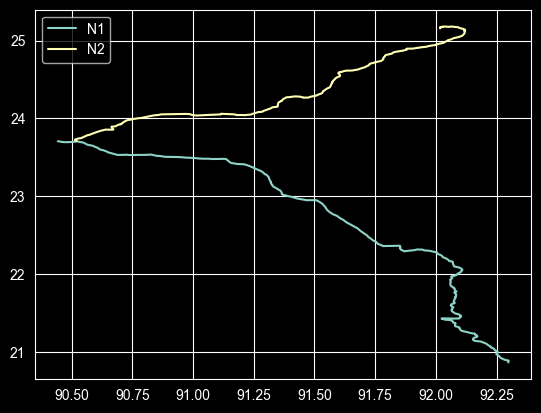

In [6]:
# Visual inspection of N1 and N2
import matplotlib.pyplot as plt

df_plot = dfN[dfN['road'].isin(['N1', 'N2'])]

for road, data in df_plot.groupby('road'):
    plt.plot(data['lon'], data['lat'], label=road)

plt.legend()
plt.show()

In [7]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R * c

In [8]:
df_n1 = dfN[dfN['road'] == 'N1'].copy()
df_n2 = dfN[dfN['road'] == 'N2'].copy()

df_cross = df_n1.merge(df_n2, how='cross', suffixes=('_n1', '_n2'))

df_cross['distance'] = haversine(
    df_cross['lat_n1'],
    df_cross['lon_n1'],
    df_cross['lat_n2'],
    df_cross['lon_n2']
)

intersections = df_cross[df_cross['distance'] < 0.05]

intersections[['road_n1','chainage_n1','lrp_n1',
               'road_n2','chainage_n2','lrp_n2',
               'distance']]



,road_n1,chainage_n1,lrp_n1,road_n2,chainage_n2,lrp_n2,distance
15062,N1,8.763,LRP009a,N2,0.0,LRPS,0.020374


In [9]:
roads = df_filtered['road'].unique()
road_pairs = list(combinations(roads, 2))


In [10]:
all_intersections = []

for r1, r2 in road_pairs:

    df_r1 = dfN[dfN['road'] == r1]
    df_r2 = dfN[dfN['road'] == r2]

    df_cross = df_r1.merge(df_r2, how='cross', suffixes=('_1', '_2'))

    df_cross['distance'] = haversine(
        df_cross['lat_1'],
        df_cross['lon_1'],
        df_cross['lat_2'],
        df_cross['lon_2']
    )

    inter = df_cross[df_cross['distance'] < 0.05]

    all_intersections.append(inter)

intersections = pd.concat(all_intersections, ignore_index=True)
intersections[['road_1','chainage_1','lrp_1',
               'road_2','chainage_2','lrp_2',
               'distance']]

display(intersections)


,road_1,chainage_1,lrp_1,lat_1,lon_1,gap_1,type_1,name_1,road_2,chainage_2,lrp_2,lat_2,lon_2,gap_2,type_2,name_2,distance
0,N1,81.801,LRP083a,23.478944,91.117722,NaN,Culvert,Box culvert,N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati,0.048258
1,N1,81.829,LRP084,23.478972,91.117999,NaN,KmPost,Km post missing,N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati,0.019837
2,N1,81.846,LRP084a,23.478972,91.118166,NaN,"SideRoad,Left",Road to Brahmanbaria(N102),N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati,0.002835
3,N1,145.409,LRP148a,23.009556,91.381360,NaN,CrossRoad / KmPost,Intersection with N104 / Km post missing,N104,1.878,LRP001a,23.009528,91.381444,NaN,CrossRoad,Right to Comilla Left to Chittagong,0.009078
4,N1,11.936,LRP012c,23.690416,90.546583,NaN,"SideRoad,Right",Right to Syedpur (R113) left to Joydebpur N105),N105,0.000,LRPS,23.690416,90.546611,NaN,Others,"Starts of road from N1,Dhaka teknaf road at Ma...",0.002831
5,N1,8.763,LRP009a,23.706083,90.521527,NaN,"SideRoad,Left",Road to Sylhet (N2),N2,0.000,LRPS,23.705917,90.521444,NaN,Others,Road Start from N1 at Katchpur,0.020374
6,N102,82.682,LRPE,24.050611,91.114667,NaN,Others,Meet with N 2 at Sanail,N2,85.823,LRP086a,24.050833,91.114444,NaN,"SideRoad,Right",Road to Mainamoti(N102),0.033466
7,N105,12.803,LRP012a,23.785194,90.568805,NaN,CrossRoad,N2 Dhaka-Sylhet -Jaflong Road,N2,11.464,LRP012a,23.785333,90.568555,NaN,CrossRoad,Intersection with N105,0.029759
8,N105,12.803,LRP012a,23.785194,90.568805,NaN,CrossRoad,N2 Dhaka-Sylhet -Jaflong Road,N2,11.476,LRP012b,23.785389,90.568888,BS,Bridge,Bridge start,0.023229
9,N105,12.803,LRP012a,23.785194,90.568805,NaN,CrossRoad,N2 Dhaka-Sylhet -Jaflong Road,N2,11.517,LRP012c,23.785389,90.569110,BE,Bridge,Bridge end,0.037868


In [11]:
df_i1 = intersections[['road_1','lrp_1','chainage_1']].rename(columns={
    'road_1':'road',
    'lrp_1':'lrp',
    'chainage_1':'chainage'
})

df_i2 = intersections[['road_2','lrp_2','chainage_2']].rename(columns={
    'road_2':'road',
    'lrp_2':'lrp',
    'chainage_2':'chainage'
})

df_intersections = pd.concat([df_i1, df_i2]) #.drop_duplicates()

df_intersections = df_intersections.merge(
    dfN,
    on=['road','lrp','chainage'],
    how='left'
)
# print(df_intersections.head())

df_intersections['model_type'] = 'intersection'
df_intersections['length'] = 0
df_intersections['condition'] = None

df_intersections = df_intersections[['road','lrp','model_type','name','lat','lon','length','condition','chainage']]
df_intersections = df_intersections.rename(columns={'lrp':'id'})

#display(df_intersections)





In [12]:
def sync_geographical_ids(df, threshold=0.05):

    final_groups = []

    # Groepeer de dataframe per weg (bijv. N1, N2, N102)
    for road, group in df.groupby('road'):
        # Reset de referentiepunten voor elke nieuwe weg
        master_locations = []
        synced_ids = []

        group = group.copy()

        for index, row in group.iterrows():
            current_lat = row['lat']
            current_lon = row['lon']
            current_id = row['id']

            match_found = False

            # Check tegen alle eerder vastgelegde 'master' locaties van DEZE weg
            for master_lat, master_lon, master_id in master_locations:
                distance = haversine(current_lat, current_lon, master_lat, master_lon)

                if distance <= threshold:
                    # Match gevonden: gebruik het ID van de master locatie
                    synced_ids.append(master_id)
                    match_found = True
                    break

            if not match_found:
                # Geen match: dit is een nieuwe unieke locatie voor deze weg
                master_locations.append((current_lat, current_lon, current_id))
                synced_ids.append(current_id)

        # Voeg de gesynchroniseerde IDs toe aan de groep
        group['id'] = synced_ids

        # Verwijder dubbelingen binnen deze specifieke weg
        group = group.drop_duplicates('id')

        final_groups.append(group)

    # Voeg alle wegen weer samen in één DataFrame
    return pd.concat(final_groups).reset_index(drop=True)



In [13]:
df_unique = sync_geographical_ids(df_intersections)
display(df_unique)

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRP083a,intersection,Box culvert,23.478944,91.117722,0,None,81.801
1,N1,LRP148a,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,0,None,145.409
2,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0,None,11.936
3,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0,None,8.763
4,N102,LRPE,intersection,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682
5,N102,LRPS,intersection,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000
6,N104,LRP001a,intersection,Right to Comilla Left to Chittagong,23.009528,91.381444,0,None,1.878
7,N105,LRP012a,intersection,N2 Dhaka-Sylhet -Jaflong Road,23.785194,90.568805,0,None,12.803
8,N105,LRPS,intersection,"Starts of road from N1,Dhaka teknaf road at Ma...",23.690416,90.546611,0,None,0.000
9,N2,LRP117b,intersection,Road to Chunarughat(N204),24.147861,91.346444,0,None,116.294


In [14]:
df_final = pd.concat([df_filtered, df_unique], ignore_index=True)
df_final = df_final.sort_values(['road', 'chainage']).reset_index(drop=True)
df_final.head(100)

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000
1,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0,None,8.763
2,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0,None,11.936
3,N1,LRP083a,intersection,Box culvert,23.478944,91.117722,0,None,81.801
4,N1,LRP148a,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,0,None,145.409
5,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254
6,N102,LRPS,sourcesink,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000
7,N102,LRPS,intersection,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000
8,N102,LRPE,sourcesink,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682
9,N102,LRPE,intersection,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682


In [16]:
def remove_overlapping_sourcesinks(df, threshold=0.05):
    indices_to_drop = []

    for road, group in df.groupby('road'):
        # Reset index binnen de groep voor makkelijk itereren
        group = group.sort_values('chainage')
        indices = group.index.tolist()

        for i in range(len(indices)):
            for j in range(i + 1, len(indices)):
                idx_a = indices[i]
                idx_b = indices[j]

                dist = haversine(
                    df.at[idx_a, 'lat'], df.at[idx_a, 'lon'],
                    df.at[idx_b, 'lat'], df.at[idx_b, 'lon']
                )

                if dist <= threshold:
                    type_a = df.at[idx_a, 'model_type']
                    type_b = df.at[idx_b, 'model_type']

                    # Verwijder de sourcesink als de andere een ander type is
                    if type_a == 'sourcesink' and type_b != 'sourcesink':
                        indices_to_drop.append(idx_a)
                    elif type_b == 'sourcesink' and type_a != 'sourcesink':
                        indices_to_drop.append(idx_b)
                    # Als beide sourcesink zijn (dubbeling op start/eind), verwijder de tweede
                    elif type_a == 'sourcesink' and type_b == 'sourcesink':
                        indices_to_drop.append(idx_b)

    # Verwijder duplicaten uit de drop-lijst en gooi ze uit de dataframe
    df_cleaned = df.drop(index=list(set(indices_to_drop))).reset_index(drop=True)
    print(f"Systeem: {len(set(indices_to_drop))} overtollige sourcesinks verwijderd.")
    return df_cleaned

# Direct toepassen op je huidige dataframe
df_final = remove_overlapping_sourcesinks(df_final)

Systeem: 10 overtollige sourcesinks verwijderd.


In [17]:
df_final

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000
1,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0,None,8.763
2,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0,None,11.936
3,N1,LRP083a,intersection,Box culvert,23.478944,91.117722,0,None,81.801
4,N1,LRP148a,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,0,None,145.409
5,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254
6,N102,LRPS,intersection,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000
7,N102,LRPE,intersection,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682
8,N104,LRPS,sourcesink,Intersection with Z1031,23.009667,91.399416,0,None,0.000
9,N104,LRP001a,intersection,Right to Comilla Left to Chittagong,23.009528,91.381444,0,None,1.878


Hieronder worden bridges gemaakt


In [18]:
#Loading in the Bridges data
df_BMMS = pd.read_excel('./data/BMMS_overview.xlsx')

#Selecting the columns that we need
cols = [
    "road",
    "name",
    "LRPName",
    "length",
    "chainage",
    "lat",
    "lon",
    "condition",
]

bridges_BMMS = df_BMMS[cols].copy()

roads = df_filtered['road'].unique()
bridges_BMMS = bridges_BMMS[bridges_BMMS['road'].isin(roads)]

bridges_BMMS['name_clean'] = bridges_BMMS['name'].astype(str).str.replace(' ', '').str.upper()

display(bridges_BMMS.head(20))


,road,name,LRPName,length,chainage,lat,lon,condition,name_clean
0,N1,.,LRP001a,11.30,1.800,23.698739,90.458861,A,.
1,N1,.,LRP004b,6.60,4.925,23.694664,90.487775,A,.
2,N1,Kanch pur Bridge.,LRP008b,394.23,8.976,23.705060,90.523214,A,KANCHPURBRIDGE.
3,N1,NOYAPARA CULVERT,LRP010b,6.30,10.880,23.694391,90.537574,A,NOYAPARACULVERT
4,N1,ADUPUR CULVERT,LRP010c,6.30,10.897,23.694302,90.537707,A,ADUPURCULVERT
5,N1,NAYABARI KASPUR BOX CULVERT,LRP011a,8.30,11.296,23.692360,90.540918,A,NAYABARIKASPURBOXCULVERT
6,N1,KHAS PARA BOX CULVERT,LRP012a,9.30,12.239,23.688412,90.548559,A,KHASPARABOXCULVERT
7,N1,DAWAN BAG BOX CULVERT,LRP012b,6.10,12.253,23.688320,90.548650,A,DAWANBAGBOXCULVERT
8,N1,Madanpur Bridge.(L),LRP013a,27.50,12.660,23.685583,90.551208,A,MADANPURBRIDGE.(L)
9,N1,MADAN PUR (R),LRP013a,26.30,12.660,23.685583,90.551208,A,MADANPUR(R)


In [19]:
#Dropping duplicates
df_unique = bridges_BMMS.drop_duplicates(
    subset=['chainage','lat','lon'],
    keep='first'
).reset_index(drop=True)

#Filtering on bridges only
df_unique['model_type'] = 'bridge'

df_bridges = df_unique[['road','LRPName','model_type','name','lat','lon','length','condition','chainage']]

df_bridges = df_bridges.rename(columns={'LRPName':'id'})

df_final = pd.concat([df_final, df_bridges], ignore_index=True)

df_final = df_final.sort_values(['road','chainage']).reset_index(drop=True)

df_final = (
    df_final
    .assign(
        prefix=(
            df_final["name"]
            .str.replace('.', '')
            .str.lower()
            .str.strip()
            .str.extract(r"^([^(]+)", expand=False)
        )
    )
    .drop_duplicates(subset=['road','prefix'], keep='first')
    .drop(columns="prefix")
)

df_final.head(20)


,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.000
1,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.800
3,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0.00,None,8.763
4,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.976
5,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B,10.543
6,N1,LRP010b,bridge,NOYAPARA CULVERT,23.694391,90.537574,6.30,A,10.880
7,N1,LRP010c,bridge,ADUPUR CULVERT,23.694302,90.537707,6.30,A,10.897
8,N1,LRP011a,bridge,NAYABARI KASPUR BOX CULVERT,23.692360,90.540918,8.30,A,11.296
9,N1,LRP011c,bridge,NAYABARI BOX CULVERT,23.690912,90.545462,10.60,B,11.808
10,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0.00,None,11.936


In [20]:
final_df_with_links = []

for road, road_df in df_final.groupby('road'):

    road_df = road_df.sort_values('chainage').reset_index(drop=True)

    for j in range(len(road_df)):
        row = road_df.iloc[j]

        # eerste node (source)
        if j == 0:
            final_df_with_links.append(row)
            continue

        prev = road_df.iloc[j-1]

        # link locatie (midden van de twee nodes)
        lat_link = (row['lat'] + prev['lat']) / 2
        lon_link = (row['lon'] + prev['lon']) / 2

        # length of the road
        link_length = (row['chainage'] - prev['chainage']) * 1000

        link = {
            'road': road,
            'id': None,
            'model_type': 'link',
            'name': 'Link',
            'lat': lat_link,
            'lon': lon_link,
            'length': link_length,
            'condition': None,
            'chainage': (row['chainage'] + prev['chainage']) / 2
        }

        final_df_with_links.append(pd.Series(link))
        final_df_with_links.append(row)

final_df_with_links = pd.DataFrame(final_df_with_links).reset_index(drop=True)

final_df_with_links.head(20)

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.0000
1,N1,None,link,Link,23.702383,90.451097,1800.00,None,0.9000
2,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.8000
3,N1,None,link,Link,23.702411,90.490194,6963.00,None,5.2815
4,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0.00,None,8.7630
5,N1,None,link,Link,23.705572,90.522371,213.00,None,8.8695
6,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.9760
7,N1,None,link,Link,23.700730,90.529157,1567.00,None,9.7595
8,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B,10.5430
9,N1,None,link,Link,23.695395,90.536337,337.00,None,10.7115


In [21]:
intersection_length = 20  # meters

final_df_with_links.loc[
    final_df_with_links['model_type'] == 'intersection',
    'length'
] = intersection_length

In [22]:
for i in range(1, len(final_df_with_links)-1):

    if final_df_with_links.loc[i, 'model_type'] == 'link':

        prev_len = final_df_with_links.loc[i-1, 'length']
        next_len = final_df_with_links.loc[i+1, 'length']

        final_df_with_links.loc[i, 'length'] = (
            final_df_with_links.loc[i, 'length']
            - prev_len/2
            - next_len/2
        )

final_df_with_links.head(20)

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.000,None,0.0000
1,N1,None,link,Link,23.702383,90.451097,1794.350,None,0.9000
2,N1,LRP001a,bridge,.,23.698739,90.458861,11.300,A,1.8000
3,N1,None,link,Link,23.702411,90.490194,6947.350,None,5.2815
4,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,20.000,None,8.7630
5,N1,None,link,Link,23.705572,90.522371,5.885,None,8.8695
6,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.230,A,8.9760
7,N1,None,link,Link,23.700730,90.529157,1365.885,None,9.7595
8,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.000,B,10.5430
9,N1,None,link,Link,23.695395,90.536337,329.850,None,10.7115


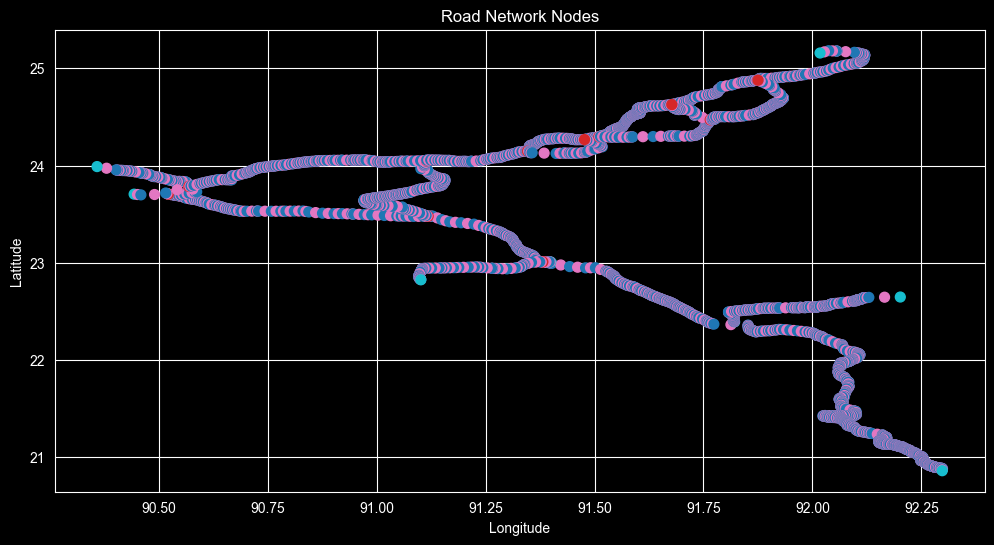

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# kleur automatisch per model_type
colors = final_df_with_links['model_type'].astype('category').cat.codes

plt.scatter(
    final_df_with_links['lon'],
    final_df_with_links['lat'],
    c=colors,
    cmap='tab10',   # mooie colormap
    s=50
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Road Network Nodes')

plt.show()

In [ ]:
Vanaf dit punt worden de IDs aangemaakt

In [34]:
THRESHOLD_KM = 0.5  # 20 meter. Pas dit aan naar bijv. 0.01 voor 10 meter.
START_ID = 1000000

df = final_df_with_links.copy()
intersections = df[df['model_type'] == 'intersection'].copy()

# We houden bij welke rij bij welk Cluster ID hoort
# We initialiseren dit met -1 (nog niet toegewezen)
intersections['temp_cluster_id'] = -1
cluster_counter = 0

# 3. Cluster de intersections op basis van afstand
inter_indices = intersections.index.tolist()

for i in range(len(inter_indices)):
    idx_i = inter_indices[i]

    # Als deze al in een cluster zit, overslaan
    if intersections.at[idx_i, 'temp_cluster_id'] != -1:
        continue

    # Start een nieuw cluster
    intersections.at[idx_i, 'temp_cluster_id'] = cluster_counter

    # Vergelijk met alle volgende intersections
    for j in range(i + 1, len(inter_indices)):
        idx_j = inter_indices[j]

        dist = haversine(
            intersections.at[idx_i, 'lat'], intersections.at[idx_i, 'lon'],
            intersections.at[idx_j, 'lat'], intersections.at[idx_j, 'lon']
        )

        if dist <= THRESHOLD_KM:
            intersections.at[idx_j, 'temp_cluster_id'] = cluster_counter

    cluster_counter += 1

# 4. ID's toewijzen aan het hoofdframe
# Geef eerst ELKE rij een uniek basis-ID (om gaten te voorkomen)
df['id'] = range(START_ID, START_ID + len(df))

# Maak een mapping tabel voor de intersection clusters
# We pakken het eerste 'basis-ID' van elk cluster om die als gedeeld ID te gebruiken
cluster_mapping = {}
for cluster_id in range(cluster_counter):
    subset = intersections[intersections['temp_cluster_id'] == cluster_id]
    shared_id = df.at[subset.index[0], 'id'] # Gebruik het ID van de eerste in het cluster
    for original_idx in subset.index:
        cluster_mapping[original_idx] = shared_id

# Overschrijf de ID's in het hoofdframe voor de intersections
for idx, shared_id in cluster_mapping.items():
    df.at[idx, 'id'] = shared_id

# 5. Resultaat controleren
print(f"Totaal aantal rijen: {len(df)}")
print(f"Unieke ID's overgebleven: {df['id'].nunique()}")
print(f"Aantal samengevoegde intersections: {len(intersections) - intersections['temp_cluster_id'].nunique()}")



display(df)

Totaal aantal rijen: 2925
Unieke ID's overgebleven: 2912
Aantal samengevoegde intersections: 13


,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,1000000,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.0000
1,N1,1000001,link,Link,23.702383,90.451097,1794.35,None,0.9000
2,N1,1000002,bridge,.,23.698739,90.458861,11.30,A,1.8000
3,N1,1000003,link,Link,23.702411,90.490194,6947.35,None,5.2815
4,N1,1000004,intersection,Road to Sylhet (N2),23.706083,90.521527,20.00,None,8.7630
...,...,...,...,...,...,...,...,...,...
2920,N208,1002920,bridge,SIB BARI BOX CULVERT,24.858606,91.885036,3.00,A,55.0400
2921,N208,1002921,link,Link,24.868345,91.880185,2044.70,None,56.0645
2922,N208,1002922,bridge,KADAM TALI BOX CULVERT,24.878083,91.875333,5.60,B,57.0890
2923,N208,1002923,link,Link,24.877819,91.875347,393.20,None,57.2920


In [37]:
duplicates = df[df.duplicated('id', keep=False)]

if duplicates.empty:
    print("Oeps! Geen dubbele ID's gevonden. De threshold was mogelijk te klein.")
else:
    print(f"Succes! Er zijn {duplicates['id'].nunique()} unieke locaties waar wegen samenkomen.")
    # Toon de eerste paar matches om te controleren
    print(duplicates[['road', 'id', 'model_type', 'lat', 'lon']].sort_values('id').head(13))

Succes! Er zijn 12 unieke locaties waar wegen samenkomen.
      road       id    model_type        lat        lon
4       N1  1000004  intersection  23.706083  90.521527
1725    N2  1000004  intersection  23.705917  90.521444
18      N1  1000018  intersection  23.690416  90.546583
1443  N105  1000018  intersection  23.690416  90.546611
126     N1  1000126  intersection  23.478944  91.117722
1177  N102  1000126  intersection  23.478972  91.118194
236     N1  1000236  intersection  23.009556  91.381360
1364  N104  1000236  intersection  23.009528  91.381444
1935    N2  1001357  intersection  24.050833  91.114444
1357  N102  1001357  intersection  24.050611  91.114667
1729    N2  1001457  intersection  23.785333  90.568555
1733    N2  1001457  intersection  23.785389  90.569110
1457  N105  1001457  intersection  23.785194  90.568805


In [38]:
# Check of er andere model_types zijn die per ongeluk hetzelfde ID hebben gekregen
check_types = duplicates.groupby('id')['model_type'].nunique()
fouten = check_types[check_types > 1]

if not fouten.empty:
    print("Waarschuwing: Er zijn verschillende model_types met hetzelfde ID!")
else:
    print("Validatie geslaagd: Alleen objecten van hetzelfde type (intersections) zijn gekoppeld.")

Validatie geslaagd: Alleen objecten van hetzelfde type (intersections) zijn gekoppeld.


In [39]:
import networkx as nx

# Maak een simpele graaf
G = nx.Graph()

# Voeg edges toe tussen de onderdelen van dezelfde weg
# We gaan ervan uit dat de rijen in de juiste volgorde per weg staan
for road, group in df.groupby('road'):
    nodes = group['id'].tolist()
    for i in range(len(nodes) - 1):
        G.add_edge(nodes[i], nodes[i+1])

# Tel het aantal losse netwerken
num_components = nx.number_connected_components(G)
print(f"Aantal losse netwerk-eilanden: {num_components}")

if num_components < df['road'].nunique():
    print("GEWELDIG: Wegen zijn succesvol aan elkaar gekoppeld via de intersections!")
else:
    print("LET OP: De wegen zijn nog steeds losse eilanden. Verhoog de THRESHOLD_KM.")

Aantal losse netwerk-eilanden: 2
GEWELDIG: Wegen zijn succesvol aan elkaar gekoppeld via de intersections!


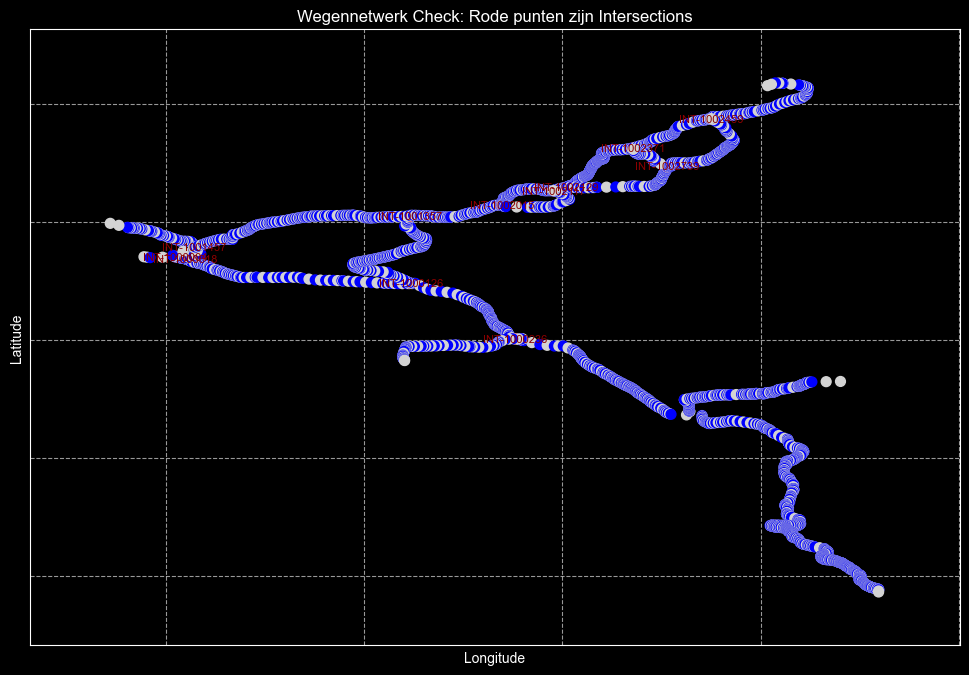

In [40]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_road_network(df):
    G = nx.Graph()
    pos = {}
    colors = []

    # 1. Bouw de graaf op basis van de opeenvolgende ID's per weg
    for road_name, group in df.groupby('road'):
        # Sorteer op index om de volgorde van de weg te behouden
        group = group.sort_index()
        nodes = group['id'].tolist()

        # Voeg nodes en hun posities toe
        for _, row in group.iterrows():
            G.add_node(row['id'])
            pos[row['id']] = (row['lon'], row['lat']) # Lon op X-as, Lat op Y-as

        # Voeg de edges (verbindingen) toe tussen de onderdelen
        for i in range(len(nodes) - 1):
            G.add_edge(nodes[i], nodes[i+1], road=road_name)

    # 2. Kleuren bepalen: Intersections krijgen een opvallende kleur
    node_colors = []
    for node_id in G.nodes():
        # Check in het originele DF wat voor type dit is
        m_type = df[df['id'] == node_id]['model_type'].iloc[0]
        if m_type == 'intersection':
            node_colors.append('red') # Intersections zijn rood
        elif m_type == 'bridge':
            node_colors.append('blue') # Bruggen zijn blauw
        else:
            node_colors.append('lightgray')

    # 3. Tekenen
    plt.figure(figsize=(12, 8))

    # Teken de wegen (edges)
    nx.draw_networkx_edges(G, pos, width=2, edge_color='black', alpha=0.5)

    # Teken de knooppunten (nodes)
    nx.draw_networkx_nodes(G, pos, node_size=50, node_color=node_colors)

    # Voeg labels toe voor de intersections om te zien of ze matchen
    inter_ids = df[df['model_type'] == 'intersection']['id'].unique()
    labels = {id: f"INT-{id}" for id in inter_ids}
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_color='darkred')

    plt.title("Wegennetwerk Check: Rode punten zijn Intersections")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Roep de functie aan
plot_road_network(df)

In [41]:
# Bekijk hoe groot de eilanden zijn
components = list(nx.connected_components(G))
for i, c in enumerate(components):
    print(f"Eiland {i+1} heeft {len(c)} knooppunten.")

# Wil je weten welke wegen in welk eiland zitten?
for i, c in enumerate(components):
    roads_in_component = df[df['id'].isin(c)]['road'].unique()
    print(f"Eiland {i+1} bevat wegen: {roads_in_component}")

Eiland 1 heeft 2709 knooppunten.
Eiland 2 heeft 203 knooppunten.
Eiland 1 bevat wegen: ['N1' 'N102' 'N104' 'N105' 'N2' 'N204' 'N207' 'N208']
Eiland 2 bevat wegen: ['N106']


In [42]:
# Bekijk de uiterste coördinaten van de losse weg N106
n106 = df[df['road'] == 'N106']
print(f"N106 bevindt zich rond: Lat {n106['lat'].mean()}, Lon {n106['lon'].mean()}")

# Bekijk de rest van het netwerk
rest = df[df['road'] != 'N106']
print(f"De rest bevindt zich rond: Lat {rest['lat'].mean()}, Lon {rest['lon'].mean()}")

N106 bevindt zich rond: Lat 22.54047443214064, Lon 91.96319954297181
De rest bevindt zich rond: Lat 23.28248324804585, Lon 91.57166701940582


In [43]:
# 1. Pak de start en het eind van de N106 (op basis van chainage)
n106_data = df[df['road'] == 'N106'].sort_values('chainage')
n106_start = n106_data.iloc[0]
n106_end = n106_data.iloc[-1]

# 2. Pak alle data van N1 en N2
n1_n2_data = df[df['road'].isin(['N1', 'N2'])]

def vind_dichtstbijzijnde(target_row, search_df):
    distances = search_df.apply(
        lambda row: haversine(target_row['lat'], target_row['lon'], row['lat'], row['lon']),
        axis=1
    )
    min_dist = distances.min()
    closest_row = search_df.loc[distances.idxmin()]
    return min_dist, closest_row

# 3. Bereken de afstanden
dist_start, row_start = vind_dichtstbijzijnde(n106_start, n1_n2_data)
dist_end, row_end = vind_dichtstbijzijnde(n106_end, n1_n2_data)

print(f"--- Analyse N106 koppeling ---")
print(f"Start N106 (Ch {n106_start['chainage']}) ligt op {dist_start:.3f} km van weg {row_start['road']} (bij Ch {row_start['chainage']})")
print(f"Eind N106 (Ch {n106_end['chainage']}) ligt op {dist_end:.3f} km van weg {row_end['road']} (bij Ch {row_end['chainage']})")

--- Analyse N106 koppeling ---
Start N106 (Ch 0.0) ligt op 3.315 km van weg N1 (bij Ch 236.99099999999999)
Eind N106 (Ch 66.85) ligt op 45.638 km van weg N1 (bij Ch 263.2425)


In [44]:
# Zoek het specifieke punt op de N1 rond chainage 237
n1_match = df[(df['road'] == 'N1') & (df['chainage'].between(236.5, 237.5))]

print("Mogelijke aansluitpunten op de N1:")
display(n1_match[['id', 'road', 'model_type', 'name', 'chainage', 'lat', 'lon']])

Mogelijke aansluitpunten op de N1:


,id,road,model_type,name,chainage,lat,lon
417,1000417,N1,link,Link,236.991,22.364795,91.813098


In [45]:
# 1. Filter alle rijen die het type 'intersection' hebben
intersections_df = df[df['model_type'] == 'intersection'].copy()

# 2. Tel hoe vaak elk ID voorkomt
# Als een ID vaker dan 1 keer voorkomt, is het een koppeling tussen wegen
id_counts = intersections_df['id'].value_counts()
intersections_df['occurrence'] = intersections_df['id'].map(id_counts)

# 3. Sorteer zodat de gekoppelde intersections bovenaan staan
intersections_overview = intersections_df.sort_values(by=['occurrence', 'id'], ascending=[False, True])

# 4. Mooi weergeven
print(f"Totaal aantal intersection-punten in data: {len(intersections_overview)}")
print(f"Aantal unieke locaties (nodes): {intersections_overview['id'].nunique()}")

# Toon de top 20 (hier zie je de dubbele ID's)
display(intersections_overview[['id', 'road', 'model_type', 'name', 'chainage', 'occurrence']].head(20))

Totaal aantal intersection-punten in data: 25
Aantal unieke locaties (nodes): 12


,id,road,model_type,name,chainage,occurrence
1457,1001457,N105,intersection,N2 Dhaka-Sylhet -Jaflong Road,12.803,3
1729,1001457,N2,intersection,Intersection with N105,11.464,3
1733,1001457,N2,intersection,Bridge end,11.517,3
4,1000004,N1,intersection,Road to Sylhet (N2),8.763,2
1725,1000004,N2,intersection,Road Start from N1 at Katchpur,0.000,2
18,1000018,N1,intersection,Right to Syedpur (R113) left to Joydebpur N105),11.936,2
1443,1000018,N105,intersection,"Starts of road from N1,Dhaka teknaf road at Ma...",0.000,2
126,1000126,N1,intersection,Box culvert,81.801,2
1177,1000126,N102,intersection,Start of road from N1 Mainamati,0.000,2
236,1000236,N1,intersection,Intersection with N104 / Km post missing,145.409,2


In [47]:
# Check alle onderdelen van N106
print(df[df['road'] == 'N106']['model_type'].value_counts())

# Kijk specifiek naar de eerste 5 rijen van N106
display(df[df['road'] == 'N106'].head(10))

model_type
link          101
bridge        100
sourcesink      2
Name: count, dtype: int64


,road,id,model_type,name,lat,lon,length,condition,chainage
1522,N106,1001522,sourcesink,Start of Road from Oxygen More,22.393555,91.821583,0.00,None,0.0000
1523,N106,1001523,link,Link,22.395515,91.820810,475.95,None,0.2385
1524,N106,1001524,bridge,TANARI BOTTOLA CULVERT,22.397475,91.820037,2.10,C,0.4770
1525,N106,1001525,link,Link,22.398957,91.819704,338.90,None,0.6475
1526,N106,1001526,bridge,TANARI BOX CULVERT,22.400440,91.819371,2.10,C,0.8180
1527,N106,1001527,link,Link,22.403193,91.819027,615.45,None,1.1270
1528,N106,1001528,bridge,BALUCHARA,22.405947,91.818683,3.00,A,1.4360
1529,N106,1001529,link,Link,22.410661,91.818916,1074.70,None,1.9785
1530,N106,1001530,bridge,NOTUN PARA,22.415375,91.819148,17.60,B,2.5210
1531,N106,1001531,link,Link,22.418794,91.819578,765.20,None,2.9090


In [51]:
# --- HANDMATIGE KOPPELING N106 AAN N1 (STAP: FINAL SNAP + TYPE FIX) ---

# 1. Definieer de matchpunten
target_n1_chainage = 236.991
n106_start_chainage = 0.0

# 2. Zoek de rij op de N1
n1_mask = (df['road'] == 'N1') & (df['chainage'].between(target_n1_chainage - 0.01, target_n1_chainage + 0.01))

if n1_mask.any():
    # Pak het ID van de N1
    n1_id = df.loc[n1_mask, 'id'].values[0]

    # Zet het model_type van de N1 op dit punt naar 'intersection'
    df.loc[n1_mask, 'model_type'] = 'intersection'

    # 3. Zoek het startpunt van de N106
    n106_mask = (df['road'] == 'N106') & (df['chainage'] == n106_start_chainage)

    if n106_mask.any():
        # Overschrijf het ID van de N106 met dat van de N1
        df.loc[n106_mask, 'id'] = n1_id

        # Zet het model_type van de N106 op dit punt ook naar 'intersection'
        df.loc[n106_mask, 'model_type'] = 'intersection'

        print(f"Koppeling geslaagd: N1 en N106 zijn nu beide 'intersection' met ID: {n1_id}")
    else:
        print("Startpunt N106 niet gevonden.")
else:
    print(f"Matchpunt op N1 rond chainage {target_n1_chainage} niet gevonden.")

# --- OVERZICHT GENEREREN ---

# Filter nu op alle ID's die vaker dan 1x voorkomen EN model_type 'intersection' zijn
id_counts = df['id'].value_counts()
shared_ids = id_counts[id_counts > 1].index

# Maak het overzicht
intersection_overzicht = df[(df['id'].isin(shared_ids)) & (df['model_type'] == 'intersection')]

# Groepeer om te zien of N1 & N106 er nu netjes in staan
overzicht_tabel = intersection_overzicht.groupby('id').agg({
    'road': lambda x: ' & '.join(sorted(x.unique())),
    'model_type': 'first',
    'name': 'first',
    'chainage': 'first'
}).reset_index()

display(overzicht_tabel[overzicht_tabel['road'].str.contains('N106')])



Koppeling geslaagd: N1 en N106 zijn nu beide 'intersection' met ID: 1000417


,id,road,model_type,name,chainage
4,1000417,N1 & N106,intersection,Link,236.991


In [54]:
# 1. Bepaal welke ID's gedeeld worden door meer dan één weg
id_counts = df.groupby('id')['road'].nunique()
shared_ids = id_counts[id_counts > 1].index

# 2. Filter het dataframe op deze gedeelde ID's
# We filteren ook op model_type 'intersection' voor de netheid
overzicht_per_weg = df[df['id'].isin(shared_ids) & (df['model_type'] == 'intersection')].copy()

# 3. Voeg de kolom 'occurrence' toe zodat je ziet hoeveel wegen dit punt delen
overzicht_per_weg['occurrence'] = overzicht_per_weg['id'].map(id_counts)

# 4. Sorteer op ID en Road zodat de matches onder elkaar staan
overzicht_per_weg = overzicht_per_weg.sort_values(['id', 'road'])

# 5. Selecteer de relevante kolommen
resultaat = overzicht_per_weg[['id', 'road', 'model_type', 'name', 'chainage', 'lat', 'lon', 'occurrence']]

print(f"Totaal aantal regels in overzicht: {len(resultaat)}")
display(resultaat)

Totaal aantal regels in overzicht: 27


,id,road,model_type,name,chainage,lat,lon,occurrence
4,1000004,N1,intersection,Road to Sylhet (N2),8.763,23.706083,90.521527,2
1725,1000004,N2,intersection,Road Start from N1 at Katchpur,0.000,23.705917,90.521444,2
18,1000018,N1,intersection,Right to Syedpur (R113) left to Joydebpur N105),11.936,23.690416,90.546583,2
1443,1000018,N105,intersection,"Starts of road from N1,Dhaka teknaf road at Ma...",0.000,23.690416,90.546611,2
126,1000126,N1,intersection,Box culvert,81.801,23.478944,91.117722,2
1177,1000126,N102,intersection,Start of road from N1 Mainamati,0.000,23.478972,91.118194,2
236,1000236,N1,intersection,Intersection with N104 / Km post missing,145.409,23.009556,91.381360,2
1364,1000236,N104,intersection,Right to Comilla Left to Chittagong,1.878,23.009528,91.381444,2
417,1000417,N1,intersection,Link,236.991,22.364795,91.813098,2
1522,1000417,N106,intersection,Start of Road from Oxygen More,0.000,22.393555,91.821583,2


In [56]:
# Filter het dataframe op model_type 'intersection'
intersections_only = df[df['model_type'] == 'intersection']

# Toon het resultaat
display(intersections_only)

# Optioneel: tel even hoeveel het er nu zijn
print(f"Totaal aantal intersections in de dataset: {len(intersections_only)}")

,road,id,model_type,name,lat,lon,length,condition,chainage
4,N1,1000004,intersection,Road to Sylhet (N2),23.706083,90.521527,20.000,None,8.763
18,N1,1000018,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,20.000,None,11.936
126,N1,1000126,intersection,Box culvert,23.478944,91.117722,20.000,None,81.801
236,N1,1000236,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,20.000,None,145.409
417,N1,1000417,intersection,Link,22.364795,91.813098,10046.175,None,236.991
1177,N102,1000126,intersection,Start of road from N1 Mainamati,23.478972,91.118194,20.000,None,0.000
1357,N102,1001357,intersection,Meet with N 2 at Sanail,24.050611,91.114667,20.000,None,82.682
1364,N104,1000236,intersection,Right to Comilla Left to Chittagong,23.009528,91.381444,20.000,None,1.878
1443,N105,1000018,intersection,"Starts of road from N1,Dhaka teknaf road at Ma...",23.690416,90.546611,20.000,None,0.000
1457,N105,1001457,intersection,N2 Dhaka-Sylhet -Jaflong Road,23.785194,90.568805,20.000,None,12.803


Totaal aantal intersections in de dataset: 27


In [57]:
# 1. Zorg dat we per weg maar één keer hetzelfde ID (knooppunt) hebben.
# We sorteren op chainage zodat we de meest logische rij (de eerste) bewaren.
df_clean = df.sort_values(['road', 'chainage']).drop_duplicates(subset=['road', 'id'], keep='first')

# 2. Update je originele dataframe variabele
df = df_clean.reset_index(drop=True)

# --- CONTROLE ---
# Check of de N2 nu nog dubbele ID's heeft in het overzicht
id_counts_n2 = df[df['road'] == 'N2']['id'].value_counts()
dubbele_ids = id_counts_n2[id_counts_n2 > 1]

if dubbele_ids.empty:
    print("Succes! Alle dubbele ID's binnen de N2 zijn verwijderd.")
else:
    print(f"Let op: er zijn nog {len(dubbele_ids)} dubbele ID's gevonden.")

# Print alleen de intersections van de N2 ter controle
display(df[(df['road'] == 'N2') & (df['model_type'] == 'intersection')])

Succes! Alle dubbele ID's binnen de N2 zijn verwijderd.


,road,id,model_type,name,lat,lon,length,condition,chainage
1725,N2,1000004,intersection,Road Start from N1 at Katchpur,23.705917,90.521444,20.0,None,0.000
1729,N2,1001457,intersection,Intersection with N105,23.785333,90.568555,20.0,None,11.464
1934,N2,1001357,intersection,Road to Mainamoti(N102),24.050833,91.114444,20.0,None,85.823
2014,N2,1002015,intersection,Road to Chunarughat(N204),24.147861,91.346444,20.0,None,116.294
2116,N2,1002117,intersection,R240 to Habiganj / N204 to Chunarughat,24.267694,91.476888,20.0,None,141.308
2128,N2,1002129,intersection,Road to Srimongal(N207),24.294722,91.510083,20.0,None,145.961
2370,N2,1002371,intersection,Road to Moulavo Bazar(N207),24.626499,91.677499,20.0,None,190.892
2458,N2,1002459,intersection,N209 / N208 to Moulovibazar,24.877694,91.875277,20.0,None,227.756


In [59]:
display(df)
print(df.head(10))

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,1000000,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.0000
1,N1,1000001,link,Link,23.702383,90.451097,1794.35,None,0.9000
2,N1,1000002,bridge,.,23.698739,90.458861,11.30,A,1.8000
3,N1,1000003,link,Link,23.702411,90.490194,6947.35,None,5.2815
4,N1,1000004,intersection,Road to Sylhet (N2),23.706083,90.521527,20.00,None,8.7630
...,...,...,...,...,...,...,...,...,...
2919,N208,1002920,bridge,SIB BARI BOX CULVERT,24.858606,91.885036,3.00,A,55.0400
2920,N208,1002921,link,Link,24.868345,91.880185,2044.70,None,56.0645
2921,N208,1002922,bridge,KADAM TALI BOX CULVERT,24.878083,91.875333,5.60,B,57.0890
2922,N208,1002923,link,Link,24.877819,91.875347,393.20,None,57.2920


  road       id    model_type  \
0   N1  1000000    sourcesink   
1   N1  1000001          link   
2   N1  1000002        bridge   
3   N1  1000003          link   
4   N1  1000004  intersection   
5   N1  1000005          link   
6   N1  1000006        bridge   
7   N1  1000007          link   
8   N1  1000008        bridge   
9   N1  1000009          link   

                                                name        lat        lon  \
0  Start of Road  after Jatrabari Flyover infront...  23.706028  90.443333   
1                                               Link  23.702383  90.451097   
2                                                  .  23.698739  90.458861   
3                                               Link  23.702411  90.490194   
4                                Road to Sylhet (N2)  23.706083  90.521527   
5                                               Link  23.705572  90.522371   
6                                  Kanch pur Bridge.  23.705060  90.523214   
7           

In [60]:
df.to_csv('data/final_network_bangladesh.csv', index=False)

In [24]:
# #Adding all bridges to final dataframe
# final_df = pd.DataFrame(columns=['road', 'id', 'model_type', 'name', 'lat', 'lon', 'length', 'condition', 'chainage'])
#
# final_df = pd.concat([source, export_df, sink], ignore_index=True)
# final_df = final_df.sort_values('chainage').reset_index(drop=True)
# final_df
# #Filtering the names in final_df with the help of a regex function that processes the string until the first '('. If after replacing dots, lowercase and strip, the names are exactly the same for two bridges, the bridge is treated as duplicate and is deleted.
# final_df = (
#     final_df
#     .assign(
#         prefix=(
#             final_df["name"]
#             .str.replace('.', '')
#             .str.lower()
#             .str.strip()
#             .str.extract(r"^([^(]+)", expand=False)
#         )
#     )
#     .drop_duplicates(subset="prefix", keep="first")
#     .drop(columns="prefix")
# )
#
# final_df.head(20)

In [25]:
#     #Adding the links in between the bridges. Their exact locations do not matter and are calculated based on the location of the pre- and succeeding bridge. The length of the link does matter, and is calculated based on the chainage of the two bridges it lies in between.
# final_df_with_links = []
#
# for j in range(len(final_df)):
#     row = final_df.iloc[j]
#
#     if row['model_type'] == 'source':
#         final_df_with_links.append(row)
#         continue
#
#     if row['model_type'] == 'sink':
#         final_df_with_links.append(row)
#         break
#
#     prev = final_df.iloc[j - 1]
#
#     lat_link = (row['lat'] + prev['lat']) / 2
#     lon_link = (row['lon'] + prev['lon']) / 2
#
#     link_length = (row['chainage'] - prev['chainage']) * 1000  #Because chainage is in km
#
#     link = {
#         'road': row['road'],
#         'id': None,
#         'model_type': 'link',
#         'name': 'Link',
#         'lat': lat_link,
#         'lon': lon_link,
#         'length': link_length,
#         'condition': None,
#         'chainage': (row['chainage'] + prev['chainage']) / 2
#     }
#
#     final_df_with_links.append(pd.Series(link))
#     final_df_with_links.append(row)
#
# final_df_with_links = (
#     pd.DataFrame(final_df_with_links)
#     .reset_index(drop=True)
#     .drop(columns='chainage')
# )
#
# final_df_with_links['id'] = 100000 + (final_df_with_links.index + 1)
#
# final_df_with_links.head(20)